<a href="https://colab.research.google.com/github/taobaid/Year-3-Project-Discharge-Audio-Signal-Classification/blob/main/audio_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

zip_path = "/content/drive/MyDrive/hv audio.zip"
extract_path = "/content/hv_audio"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

data_dir = extract_path
# check to display 9 categories
!ls -1 "/content/hv_audio" | head -n 20

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ac corona from conductor
ac corona from insulator
ac dry band arcing
+dc corona from conductor
-dc corona from conductor
+dc corona from insulator
-dc corona from insulator
+dc dry band arcing
-dc dry band arcing


In [2]:
import os, glob, re, math
import numpy as np
import pandas as pd
import soundfile as sf

from scipy.signal import stft, resample_poly
from scipy.fftpack import dct

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# Optional XGBoost
!pip -q install xgboost
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

In [3]:

def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)

def mel_to_hz(m):
    return 700 * (10 ** (m / 2595) - 1)

def mel_filterbank(sr, n_fft, n_mels=40, fmin=0.0, fmax=None):
    if fmax is None:
        fmax = sr / 2

    mels = np.linspace(hz_to_mel(fmin), hz_to_mel(fmax), n_mels + 2)
    hz = mel_to_hz(mels)
    bins = np.floor((n_fft + 1) * hz / sr).astype(int)

    fb = np.zeros((n_mels, n_fft // 2 + 1), dtype=np.float32)
    for i in range(1, n_mels + 1):
        left, center, right = bins[i - 1], bins[i], bins[i + 1]
        center = max(center, left + 1)
        right = max(right, center + 1)

        for j in range(left, center):
            if 0 <= j < fb.shape[1]:
                fb[i - 1, j] = (j - left) / (center - left)
        for j in range(center, right):
            if 0 <= j < fb.shape[1]:
                fb[i - 1, j] = (right - j) / (right - center)
    return fb

def extract_audio_features(
    path,
    target_sr=22050,
    duration=3.0,
    n_fft=1024,
    hop=512,
    n_mels=40,
    n_mfcc=20
):
    y, sr = sf.read(path)
    if y.ndim > 1:
        y = y.mean(axis=1)  # stereo -> mono

    # Resample if needed
    if sr != target_sr:
        g = math.gcd(sr, target_sr)
        y = resample_poly(y, target_sr // g, sr // g)
        sr = target_sr

    # Fixed length (pad/trim)
    N = int(duration * sr)
    y = y[:N] if len(y) >= N else np.pad(y, (0, N - len(y)))

    # Pre-emphasis
    y = np.append(y[0], y[1:] - 0.97 * y[:-1])

    # STFT power
    f, t, Z = stft(
        y, fs=sr,
        nperseg=n_fft,
        noverlap=n_fft - hop,
        nfft=n_fft,
        boundary=None,
        padded=False
    )
    S = (np.abs(Z) ** 2).astype(np.float32)

    # log-mel
    fb = mel_filterbank(sr, n_fft, n_mels=n_mels)
    mel_spec = fb @ S
    mel_spec = np.maximum(mel_spec, 1e-10)
    log_mel = np.log(mel_spec)

    # MFCC
    mfcc = dct(log_mel, type=2, axis=0, norm="ortho")[:n_mfcc]

    def stats(mat):
        return np.hstack([mat.mean(axis=1), mat.std(axis=1)])

    rms = np.sqrt(np.mean(S, axis=0, keepdims=True))

    feat = np.hstack([
        stats(mfcc),
        stats(log_mel),
        stats(rms),
    ]).astype(np.float32)

    return feat

In [4]:
def label9_from_folder(folder_name: str) -> str:
    return folder_name.strip().lower().replace(" ", "_")

def group_id_from_filename(path: str) -> str:
    base = os.path.basename(path)
    base = re.sub(r"\.(wav|flac|mp3)$", "", base, flags=re.IGNORECASE)
    base = re.sub(r"_seg_\d+$", "", base, flags=re.IGNORECASE)
    base = re.sub(r"\s+", " ", base).strip()
    return base

def build_df_from_folders(root_dir: str, exts=(".wav", ".flac", ".mp3"),
                          duration=3.0, target_sr=22050):
    rows = []
    class_folders = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
    if not class_folders:
        raise RuntimeError(f"No class folders found under: {root_dir}")

    for folder in sorted(class_folders):
        folder_path = os.path.join(root_dir, folder)
        label9 = label9_from_folder(folder)

        files = []
        for ext in exts:
            files.extend(glob.glob(os.path.join(folder_path, f"*{ext}")))
        files = sorted(files)

        if not files:
            print(f"Warning: no audio files in {folder_path}")
            continue

        for p in files:
            try:
                feat = extract_audio_features(p, duration=duration, target_sr=target_sr)
                rows.append({
                    "path": p,
                    "label9": label9,
                    "group": group_id_from_filename(p),
                    "features": feat
                })
            except Exception as e:
                print(f"Skipping {p}: {e}")

    if not rows:
        raise RuntimeError("No usable audio files after extraction.")

    X = np.vstack([r["features"] for r in rows])
    df = pd.DataFrame(X, columns=[f"f{i}" for i in range(X.shape[1])])
    df["path"] = [r["path"] for r in rows]
    df["label9"] = [r["label9"] for r in rows]
    df["group"] = [r["group"] for r in rows]
    return df

In [5]:
ROOT = "/content/hv_audio"   # change if path differs

df = build_df_from_folders(ROOT, duration=3.0, target_sr=22050)

print("Files:", len(df))
print("Feature dims:", df.filter(like="f").shape[1])
print("Classes (9):", df["label9"].nunique())
print("Groups:", df["group"].nunique())

print("\nFiles per class:\n", df["label9"].value_counts())
print("\nGroups per class:\n", df.drop_duplicates(["label9","group"]).groupby("label9")["group"].nunique().sort_values())

# sanity on features
X_np = df.filter(like="f").to_numpy()
print("\nAny NaN?", np.isnan(X_np).any(), "Any inf?", np.isinf(X_np).any())

Files: 1251
Feature dims: 122
Classes (9): 9
Groups: 29

Files per class:
 label9
ac_corona_from_conductor     254
-dc_corona_from_conductor    247
ac_dry_band_arcing           198
+dc_corona_from_conductor    149
-dc_corona_from_insulator    129
+dc_dry_band_arcing          112
-dc_dry_band_arcing           67
ac_corona_from_insulator      55
+dc_corona_from_insulator     40
Name: count, dtype: int64

Groups per class:
 label9
ac_corona_from_insulator     1
+dc_corona_from_insulator    2
ac_dry_band_arcing           2
+dc_dry_band_arcing          3
-dc_dry_band_arcing          3
+dc_corona_from_conductor    3
-dc_corona_from_insulator    4
ac_corona_from_conductor     5
-dc_corona_from_conductor    6
Name: group, dtype: int64

Any NaN? False Any inf? False


In [6]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier

def constrained_group_split(df, target_col, group_col="group",
                             test_size=0.2, required_classes=None,
                             max_tries=500, random_state=42):
    X = df.filter(like="f")
    y = df[target_col]
    groups = df[group_col]

    rng = np.random.RandomState(random_state)
    for _ in range(max_tries):
        seed = rng.randint(0, 1_000_000)
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        train_idx, test_idx = next(gss.split(X, y, groups))
        if required_classes.issubset(set(y.iloc[test_idx].unique())):
            return train_idx, test_idx

    raise RuntimeError("Could not find a split that includes all required classes.")

# evaluate polarity with +dc forced into test
X = df.filter(like="f")
groups = df["group"]

df["polarity"] = df["label9"].apply(
    lambda s: "+dc" if s.startswith("+dc") else ("-dc" if s.startswith("-dc") else "ac")
)

train_idx, test_idx = constrained_group_split(
    df,
    target_col="polarity",
    required_classes={"+dc", "-dc", "ac"}
)

# sanity check
overlap = set(groups.iloc[train_idx]).intersection(set(groups.iloc[test_idx]))
print("Polarity | group overlap:", len(overlap))
print("Test polarity counts:\n", df.iloc[test_idx]["polarity"].value_counts())

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = df["polarity"].iloc[train_idx], df["polarity"].iloc[test_idx]

rf_pol = RandomForestClassifier(
    n_estimators=600, random_state=42, n_jobs=-1, class_weight="balanced"
)
rf_pol.fit(X_train, y_train)
pred = rf_pol.predict(X_test)

print("Polarity accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

# evaluate kind
df["kind"] = df["label9"].apply(
    lambda s: "dry_band_arcing" if "dry_band_arcing" in s else ("conductor" if "conductor" in s else "insulator")
)

pol_train_idx, pol_test_idx = constrained_group_split(
    df,
    target_col="polarity",
    required_classes={"+dc", "-dc", "ac"}
)

kind_train_idx, kind_test_idx = constrained_group_split(
    df,
    target_col="kind",
    required_classes={"conductor", "insulator", "dry_band_arcing"}
)

overlap = set(groups.iloc[train_idx]).intersection(set(groups.iloc[test_idx]))
print("\nKind | group overlap:", len(overlap))
print("Test kind counts:\n", df.iloc[test_idx]["kind"].value_counts())

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = df["kind"].iloc[train_idx], df["kind"].iloc[test_idx]

rf_kind = RandomForestClassifier(
    n_estimators=600, random_state=42, n_jobs=-1, class_weight="balanced"
)
rf_kind.fit(X_train, y_train)
pred = rf_kind.predict(X_test)

print("Kind accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Polarity | group overlap: 0
Test polarity counts:
 polarity
ac     251
+dc     75
-dc     39
Name: count, dtype: int64
Polarity accuracy: 0.4328767123287671
              precision    recall  f1-score   support

         +dc       0.86      1.00      0.93        75
         -dc       0.10      0.56      0.18        39
          ac       0.92      0.24      0.38       251

    accuracy                           0.43       365
   macro avg       0.63      0.60      0.50       365
weighted avg       0.82      0.43      0.47       365


Kind | group overlap: 0
Test kind counts:
 kind
dry_band_arcing    183
conductor          143
insulator           39
Name: count, dtype: int64
Kind accuracy: 0.7945205479452054
                 precision    recall  f1-score   support

      conductor       0.88      0.65      0.75       143
dry_band_arcing       0.75      1.00      0.86       183
      insulator       1.00      0.36      0.53        39

       accuracy                           0.79       3

In [7]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# rebuild feature matrix
X = df.filter(like="f")

# polarity test
X_train_pol  = X.iloc[pol_train_idx]
X_test_pol   = X.iloc[pol_test_idx]
y_train_pol  = df["polarity"].iloc[pol_train_idx]
y_test_pol   = df["polarity"].iloc[pol_test_idx]

# kind test-
X_train_kind = X.iloc[kind_train_idx]
X_test_kind  = X.iloc[kind_test_idx]
y_train_kind = df["kind"].iloc[kind_train_idx]
y_test_kind  = df["kind"].iloc[kind_test_idx]

def train_eval_xgb(task_name, X_train, X_test, y_train, y_test):
    # Encode string labels -> 0..K-1
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train.astype(str))
    y_test_enc  = le.transform(y_test.astype(str))

    model = XGBClassifier(
        n_estimators=800,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        min_child_weight=1,
        gamma=0,
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42
    )
    model.fit(X_train, y_train_enc)

    pred_enc = model.predict(X_test)
    pred = le.inverse_transform(pred_enc)

    print(f"\n XGBoost: {task_name} ")
    print("Accuracy:", accuracy_score(y_test.astype(str), pred))
    print(classification_report(y_test.astype(str), pred))
    return model, le

X_train_kind = X.iloc[kind_train_idx]
X_test_kind  = X.iloc[kind_test_idx]
y_train_kind = df["kind"].iloc[kind_train_idx]
y_test_kind  = df["kind"].iloc[kind_test_idx]

xgb_pol, le_pol = train_eval_xgb("polarity", X_train_pol, X_test_pol, y_train_pol, y_test_pol)
xgb_kind, le_kind = train_eval_xgb("kind", X_train_kind, X_test_kind, y_train_kind, y_test_kind)


 XGBoost: polarity 
Accuracy: 0.6
              precision    recall  f1-score   support

         +dc       0.79      0.65      0.72        75
         -dc       0.15      0.56      0.23        39
          ac       0.97      0.59      0.73       251

    accuracy                           0.60       365
   macro avg       0.64      0.60      0.56       365
weighted avg       0.85      0.60      0.68       365


 XGBoost: kind 
Accuracy: 0.5041095890410959
                 precision    recall  f1-score   support

      conductor       0.47      0.99      0.64       143
dry_band_arcing       0.58      0.15      0.24       183
      insulator       0.94      0.38      0.55        39

       accuracy                           0.50       365
      macro avg       0.66      0.51      0.47       365
   weighted avg       0.58      0.50      0.43       365



In [11]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# xgboost implementation
from xgboost import XGBClassifier

# preapre splits per task
X = df.filter(like="f")

# force all classes to appear in test
pol_train_idx, pol_test_idx = constrained_group_split(
    df, target_col="polarity", required_classes={"+dc", "-dc", "ac"}
)
kind_train_idx, kind_test_idx = constrained_group_split(
    df, target_col="kind", required_classes={"conductor", "insulator", "dry_band_arcing"}
)

splits = {
    "polarity": (pol_train_idx, pol_test_idx, df["polarity"]),
    "kind": (kind_train_idx, kind_test_idx, df["kind"]),
}

# models being compared:
# scaling models: LR, SVM, KNN, MLP, NB
# tree models: RF, ExtraTrees, GBoost, XGB
models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))
    ]),
    "SVM-RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=15))
    ]),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42))
    ]),
    "GaussianNB": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GaussianNB())
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=600, random_state=42, n_jobs=-1, class_weight="balanced"
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=800, random_state=42, n_jobs=-1, class_weight="balanced"
    ),
    "GradBoost": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=800, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        reg_lambda=1.0, eval_metric="mlogloss", tree_method="hist",
        random_state=42
    ),
}

# evaluation helper
def fit_predict(model, X_train, y_train, X_test):
    """
    Handles XGBoost label encoding (strings -> ints) and returns string predictions.
    """
    if isinstance(model, XGBClassifier):
        le = LabelEncoder()
        y_train_enc = le.fit_transform(y_train.astype(str))
        model.fit(X_train, y_train_enc)
        pred_enc = model.predict(X_test)
        pred = le.inverse_transform(pred_enc)
        return pred
    else:
        model.fit(X_train, y_train)
        return model.predict(X_test)

rows = []

for task_name, (train_idx, test_idx, y_all) in splits.items():
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_all.iloc[train_idx].astype(str), y_all.iloc[test_idx].astype(str)

    print(f"TASK: {task_name}")
    print("Test class counts:", y_test.value_counts().to_dict())

    for name, model in models.items():
        pred = fit_predict(model, X_train, y_train, X_test)

        acc = accuracy_score(y_test, pred)
        mf1 = f1_score(y_test, pred, average="macro")

        rows.append({
            "task": task_name,
            "model": name,
            "accuracy": acc,
            "macro_f1": mf1
        })

results = pd.DataFrame(rows).sort_values(["task", "macro_f1"], ascending=[True, False])
results

TASK: polarity
Test class counts: {'ac': 251, '+dc': 75, '-dc': 39}
TASK: kind
Test class counts: {'dry_band_arcing': 183, 'conductor': 143, 'insulator': 39}


,task,model,accuracy,macro_f1
15,kind,ExtraTrees,0.915068,0.804869
11,kind,KNN,0.876712,0.771230
14,kind,RandomForest,0.794521,0.710143
13,kind,GaussianNB,0.821918,0.601176
10,kind,SVM-RBF,0.526027,0.511131
16,kind,GradBoost,0.539726,0.501350
17,kind,XGBoost,0.504110,0.474338
9,kind,LogReg,0.457534,0.436878
12,kind,MLP,0.446575,0.375027
8,polarity,XGBoost,0.600000,0.560466


In [9]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import numpy as np
import pandas as pd

def crossval_predict_strings(model, X_train, y_train, X_valid):
    model = clone(model)

    if isinstance(model, XGBClassifier):
        le = LabelEncoder()
        y_train_enc = le.fit_transform(y_train.astype(str))
        model.fit(X_train, y_train_enc)
        pred_enc = model.predict(X_valid)
        pred = le.inverse_transform(pred_enc)
        return pred
    else:
        model.fit(X_train, y_train.astype(str))
        return model.predict(X_valid)

def groups_per_class(df, target_col, group_col="group"):
    return (
        df[[target_col, group_col]]
        .drop_duplicates()
        .groupby(target_col)[group_col]
        .nunique()
        .sort_values()
    )

def grouped_cv_scores(X, y, groups, models, n_splits=5):
    gkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    rows = []

    for model_name, model in models.items():
        fold_acc = []
        fold_f1 = []

        for fold, (train_idx, valid_idx) in enumerate(gkf.split(X, y, groups), start=1):
            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y.iloc[train_idx].astype(str), y.iloc[valid_idx].astype(str)

            pred = crossval_predict_strings(model, X_train, y_train, X_valid)

            acc = accuracy_score(y_valid, pred)
            mf1 = f1_score(y_valid, pred, average="macro")

            fold_acc.append(acc)
            fold_f1.append(mf1)

            rows.append({
                "model": model_name,
                "fold": fold,
                "accuracy": acc,
                "macro_f1": mf1
            })

        print(
            f"{model_name:12s} | "
            f"acc = {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f} | "
            f"macro_f1 = {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}"
        )

    fold_df = pd.DataFrame(rows)
    summary_df = (
        fold_df.groupby("model")
        .agg(
            accuracy_mean=("accuracy", "mean"),
            accuracy_std=("accuracy", "std"),
            macro_f1_mean=("macro_f1", "mean"),
            macro_f1_std=("macro_f1", "std")
        )
        .sort_values("macro_f1_mean", ascending=False)
        .reset_index()
    )
    return fold_df, summary_df

In [10]:
cv_models = {
    "LogReg": models["LogReg"],
    "KNN": models["KNN"],
    "RandomForest": models["RandomForest"],
    "ExtraTrees": models["ExtraTrees"],
    "GaussianNB": models["GaussianNB"],
    "XGBoost": models["XGBoost"],
}

X = df.filter(like="f")
groups = df["group"]

task_targets = {
    "polarity": df["polarity"].astype(str),
    "kind": df["kind"].astype(str),
}

cv_summaries = {}
cv_folds = {}

for task_name, y_task in task_targets.items():
    print("\n")
    print(f"GROUPED CROSS-VALIDATION: {task_name}")
    print("Class counts:", Counter(y_task))

    gpc = groups_per_class(df.assign(target=y_task), "target")
    print("Groups per class:\n", gpc)

    n_splits_task = min(5, int(gpc.min()))
    print(f"Using n_splits = {n_splits_task}")
    print("\n")

    fold_df, summary_df = grouped_cv_scores(
        X=X,
        y=y_task,
        groups=groups,
        models=cv_models,
        n_splits=n_splits_task
    )

    cv_folds[task_name] = fold_df
    cv_summaries[task_name] = summary_df

    display(summary_df)



GROUPED CROSS-VALIDATION: polarity
Class counts: Counter({'ac': 507, '-dc': 443, '+dc': 301})
Groups per class:
 target
+dc     8
ac      8
-dc    13
Name: group, dtype: int64
Using n_splits = 5


LogReg       | acc = 0.4144 ± 0.1455 | macro_f1 = 0.3902 ± 0.1451
KNN          | acc = 0.5656 ± 0.1401 | macro_f1 = 0.5456 ± 0.1374
RandomForest | acc = 0.4123 ± 0.1516 | macro_f1 = 0.4063 ± 0.1835
ExtraTrees   | acc = 0.5429 ± 0.1658 | macro_f1 = 0.4861 ± 0.1034
GaussianNB   | acc = 0.2278 ± 0.1316 | macro_f1 = 0.1609 ± 0.1281
XGBoost      | acc = 0.4407 ± 0.1436 | macro_f1 = 0.4072 ± 0.1785


,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std
0,KNN,0.565602,0.156594,0.545573,0.153605
1,ExtraTrees,0.542888,0.185393,0.486106,0.115597
2,XGBoost,0.440661,0.160519,0.407179,0.199612
3,RandomForest,0.412291,0.169468,0.406336,0.205209
4,LogReg,0.414375,0.162725,0.390219,0.162195
5,GaussianNB,0.227757,0.147088,0.160903,0.143253




GROUPED CROSS-VALIDATION: kind
Class counts: Counter({'conductor': 650, 'dry_band_arcing': 377, 'insulator': 224})
Groups per class:
 target
insulator           7
dry_band_arcing     8
conductor          14
Name: group, dtype: int64
Using n_splits = 5


LogReg       | acc = 0.6025 ± 0.2827 | macro_f1 = 0.4547 ± 0.2186
KNN          | acc = 0.7018 ± 0.2444 | macro_f1 = 0.4618 ± 0.1830
RandomForest | acc = 0.5803 ± 0.2348 | macro_f1 = 0.4790 ± 0.2401
ExtraTrees   | acc = 0.6379 ± 0.2281 | macro_f1 = 0.4853 ± 0.1861
GaussianNB   | acc = 0.5978 ± 0.1807 | macro_f1 = 0.2989 ± 0.0986
XGBoost      | acc = 0.5269 ± 0.2091 | macro_f1 = 0.3994 ± 0.1680


,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std
0,ExtraTrees,0.637924,0.255035,0.485294,0.208023
1,RandomForest,0.580250,0.262485,0.478998,0.268469
2,KNN,0.701751,0.273261,0.461828,0.204597
3,LogReg,0.602493,0.316092,0.454672,0.244405
4,XGBoost,0.526904,0.233805,0.399422,0.187874
5,GaussianNB,0.597809,0.202014,0.298878,0.110255


In [12]:
def make_pretty_table(results_df, task_name):
    df = results_df[results_df["task"] == task_name].copy()

    # sort by macro F1
    df = df.sort_values("macro_f1", ascending=False)

    # Round values
    df["accuracy"] = df["accuracy"].round(3)
    df["macro_f1"] = df["macro_f1"].round(3)

    # rename columns (for using in report later)
    df = df.rename(columns={
        "model": "Model",
        "accuracy": "Accuracy",
        "macro_f1": "Macro F1"
    })

    return df[["Model", "Accuracy", "Macro F1"]]

kind_table = make_pretty_table(results, "kind")
polarity_table = make_pretty_table(results, "polarity")

display(kind_table)
display(polarity_table)

,Model,Accuracy,Macro F1
15,ExtraTrees,0.915,0.805
11,KNN,0.877,0.771
14,RandomForest,0.795,0.710
13,GaussianNB,0.822,0.601
10,SVM-RBF,0.526,0.511
16,GradBoost,0.540,0.501
17,XGBoost,0.504,0.474
9,LogReg,0.458,0.437
12,MLP,0.447,0.375


,Model,Accuracy,Macro F1
8,XGBoost,0.600,0.560
3,MLP,0.515,0.534
5,RandomForest,0.433,0.495
6,ExtraTrees,0.419,0.478
2,KNN,0.427,0.463
7,GradBoost,0.397,0.444
0,LogReg,0.463,0.382
1,SVM-RBF,0.384,0.293
4,GaussianNB,0.134,0.079


In [13]:
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import LabelEncoder

def fit_model_and_predict_strings(model, X_train, y_train, X_test):
    model = clone(model)

    if isinstance(model, XGBClassifier):
        le = LabelEncoder()
        y_train_enc = le.fit_transform(y_train.astype(str))
        model.fit(X_train, y_train_enc)
        pred_enc = model.predict(X_test)
        pred = le.inverse_transform(pred_enc)
    else:
        model.fit(X_train, y_train.astype(str))
        pred = model.predict(X_test)

    return model, pred

def plot_task_confusion_matrix(task_name, preferred_order=None, normalize=None):
    summary_df = cv_summaries[task_name]
    best_model_name = summary_df.iloc[0]["model"]
    best_model = cv_models[best_model_name]

    train_idx, test_idx, y_all = splits[task_name]
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train = y_all.iloc[train_idx].astype(str)
    y_test = y_all.iloc[test_idx].astype(str)

    fitted_model, pred = fit_model_and_predict_strings(best_model, X_train, y_train, X_test)

    labels = preferred_order if preferred_order is not None else sorted(y_test.unique())

    print(f"Best model for {task_name}: {best_model_name}")
    print(classification_report(y_test, pred, labels=labels, zero_division=0))

    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        labels=labels,
        cmap="Blues",
        normalize=normalize,
        xticks_rotation=30,
        ax=ax
    )
    ax.set_title(f"{task_name.title()} confusion matrix ({best_model_name})")
    plt.tight_layout()
    plt.show()

In [14]:
kind_table.to_csv("kind_results.csv", index=False)
polarity_table.to_csv("polarity_results.csv", index=False)

Best model for polarity: KNN
              precision    recall  f1-score   support

          ac       0.84      0.33      0.47       251
         +dc       0.82      0.85      0.84        75
         -dc       0.05      0.23      0.08        39

    accuracy                           0.43       365
   macro avg       0.57      0.47      0.46       365
weighted avg       0.75      0.43      0.51       365



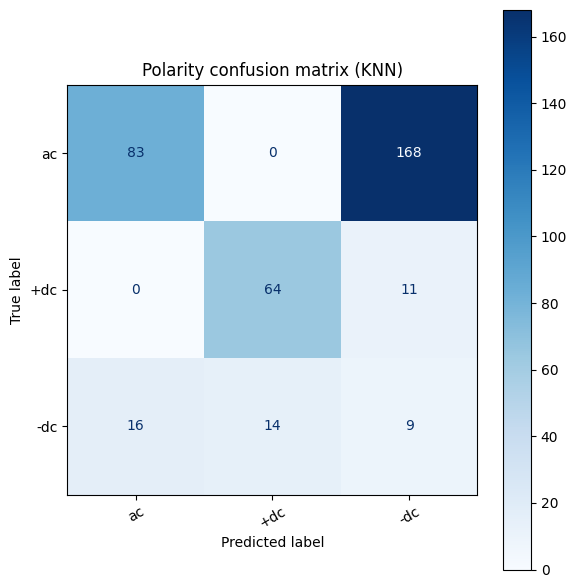

Best model for kind: ExtraTrees
                 precision    recall  f1-score   support

      conductor       0.90      0.96      0.93       143
      insulator       1.00      0.36      0.53        39
dry_band_arcing       0.92      1.00      0.96       183

       accuracy                           0.92       365
      macro avg       0.94      0.77      0.80       365
   weighted avg       0.92      0.92      0.90       365



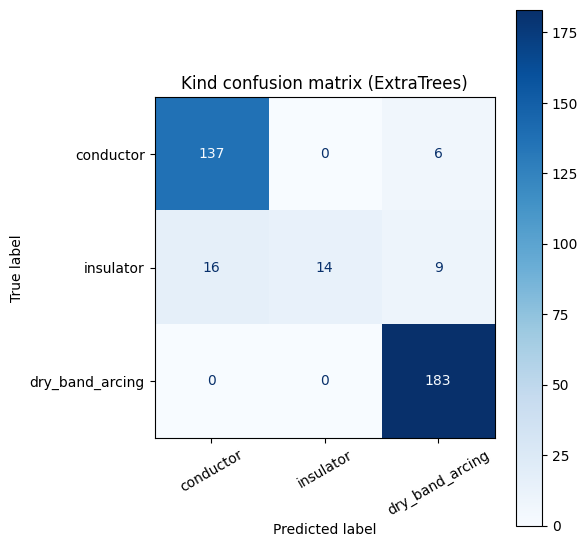

In [15]:
plot_task_confusion_matrix("polarity", preferred_order=["ac", "+dc", "-dc"], normalize=None)
plot_task_confusion_matrix("kind", preferred_order=["conductor", "insulator", "dry_band_arcing"], normalize=None)

Best model for polarity: KNN
              precision    recall  f1-score   support

          ac       0.84      0.33      0.47       251
         +dc       0.82      0.85      0.84        75
         -dc       0.05      0.23      0.08        39

    accuracy                           0.43       365
   macro avg       0.57      0.47      0.46       365
weighted avg       0.75      0.43      0.51       365



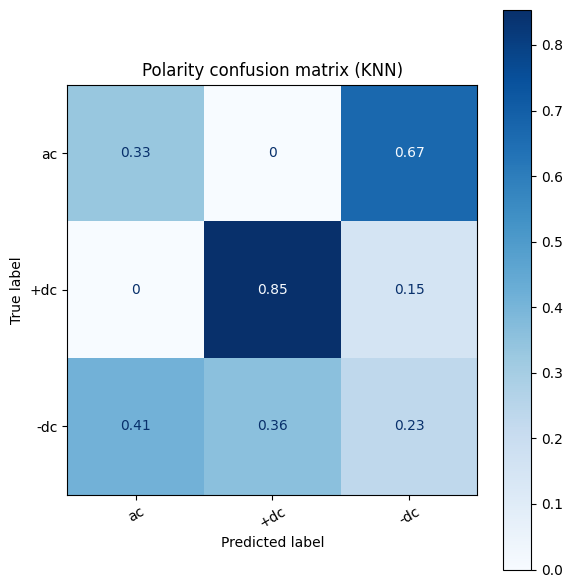

Best model for kind: ExtraTrees
                 precision    recall  f1-score   support

      conductor       0.90      0.96      0.93       143
      insulator       1.00      0.36      0.53        39
dry_band_arcing       0.92      1.00      0.96       183

       accuracy                           0.92       365
      macro avg       0.94      0.77      0.80       365
   weighted avg       0.92      0.92      0.90       365



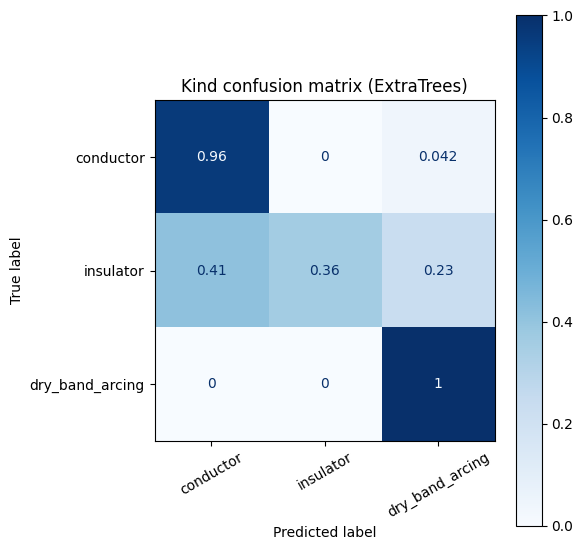

In [16]:
plot_task_confusion_matrix("polarity", preferred_order=["ac", "+dc", "-dc"], normalize="true")
plot_task_confusion_matrix("kind", preferred_order=["conductor", "insulator", "dry_band_arcing"], normalize="true")

In [17]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# fit + predict strings
def fit_predict_strings(model, X_train, y_train, X_test):
    model = clone(model)

    if isinstance(model, XGBClassifier):
        le = LabelEncoder()
        y_train_enc = le.fit_transform(y_train.astype(str))
        model.fit(X_train, y_train_enc)
        pred_enc = model.predict(X_test)
        pred = le.inverse_transform(pred_enc)
        return pred
    else:
        model.fit(X_train, y_train.astype(str))
        return model.predict(X_test)

# repeated constrained split evaluation
def repeated_constrained_eval(
    df,
    target_col,
    model,
    required_classes,
    n_repeats=20,
    test_size=0.2,
    base_seed=42
):
    X = df.filter(like="f")
    rows = []

    for i in range(n_repeats):
        seed = base_seed + i

        train_idx, test_idx = constrained_group_split(
            df,
            target_col=target_col,
            required_classes=required_classes,
            test_size=test_size,
            random_state=seed
        )

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = df[target_col].iloc[train_idx].astype(str)
        y_test = df[target_col].iloc[test_idx].astype(str)

        pred = fit_predict_strings(model, X_train, y_train, X_test)

        acc = accuracy_score(y_test, pred)
        mf1 = f1_score(y_test, pred, average="macro")

        rows.append({
            "repeat": i + 1,
            "seed": seed,
            "accuracy": acc,
            "macro_f1": mf1,
            "test_counts": dict(y_test.value_counts())
        })

    repeat_df = pd.DataFrame(rows)

    summary = {
        "accuracy_mean": repeat_df["accuracy"].mean(),
        "accuracy_std": repeat_df["accuracy"].std(),
        "macro_f1_mean": repeat_df["macro_f1"].mean(),
        "macro_f1_std": repeat_df["macro_f1"].std()
    }

    return repeat_df, summary

# select best models
best_kind_model = models["ExtraTrees"]
best_polarity_model = models["XGBoost"]

# run repeated evaluation
kind_repeats, kind_summary = repeated_constrained_eval(
    df=df,
    target_col="kind",
    model=best_kind_model,
    required_classes={"conductor", "insulator", "dry_band_arcing"},
    n_repeats=20,
    test_size=0.2,
    base_seed=100
)

pol_repeats, pol_summary = repeated_constrained_eval(
    df=df,
    target_col="polarity",
    model=best_polarity_model,
    required_classes={"+dc", "-dc", "ac"},
    n_repeats=20,
    test_size=0.2,
    base_seed=200
)

# print summary
print("Repeated constrained split results\n")

print("Kind classification (ExtraTrees)")
print(f"Accuracy  : {kind_summary['accuracy_mean']:.3f} ± {kind_summary['accuracy_std']:.3f}")
print(f"Macro F1  : {kind_summary['macro_f1_mean']:.3f} ± {kind_summary['macro_f1_std']:.3f}\n")

print("Polarity classification (XGBoost)")
print(f"Accuracy  : {pol_summary['accuracy_mean']:.3f} ± {pol_summary['accuracy_std']:.3f}")
print(f"Macro F1  : {pol_summary['macro_f1_mean']:.3f} ± {pol_summary['macro_f1_std']:.3f}\n")

#  display per-repeat details
print("Per-repeat results: kind")
display(kind_repeats[["repeat", "seed", "accuracy", "macro_f1", "test_counts"]])

print("Per-repeat results: polarity")
display(pol_repeats[["repeat", "seed", "accuracy", "macro_f1", "test_counts"]])

Repeated constrained split results

Kind classification (ExtraTrees)
Accuracy  : 0.615 ± 0.182
Macro F1  : 0.507 ± 0.160

Polarity classification (XGBoost)
Accuracy  : 0.470 ± 0.157
Macro F1  : 0.416 ± 0.155

Per-repeat results: kind


,repeat,seed,accuracy,macro_f1,test_counts
0,1,100,0.682415,0.578563,"{'dry_band_arcing': 198, 'insulator': 94, 'con..."
1,2,101,0.613208,0.430538,"{'conductor': 135, 'insulator': 57, 'dry_band_..."
2,3,102,0.542308,0.377173,"{'conductor': 123, 'dry_band_arcing': 79, 'ins..."
3,4,103,0.765182,0.544519,"{'conductor': 137, 'insulator': 72, 'dry_band_..."
4,5,104,0.458204,0.333880,"{'conductor': 219, 'dry_band_arcing': 66, 'ins..."
5,6,105,0.780347,0.742463,"{'dry_band_arcing': 195, 'conductor': 80, 'ins..."
6,7,106,0.845209,0.800432,"{'dry_band_arcing': 223, 'conductor': 113, 'in..."
7,8,107,0.395349,0.390045,"{'insulator': 93, 'conductor': 80, 'dry_band_a..."
8,9,108,0.571429,0.476177,"{'conductor': 140, 'dry_band_arcing': 107, 'in..."
9,10,109,0.539474,0.544590,"{'dry_band_arcing': 77, 'insulator': 40, 'cond..."


Per-repeat results: polarity


,repeat,seed,accuracy,macro_f1,test_counts
0,1,200,0.328283,0.254448,"{'ac': 283, '+dc': 68, '-dc': 45}"
1,2,201,0.362869,0.419934,"{'+dc': 161, 'ac': 41, '-dc': 35}"
2,3,202,0.368932,0.226936,"{'ac': 96, '-dc': 84, '+dc': 26}"
3,4,203,0.295302,0.290764,"{'-dc': 93, 'ac': 37, '+dc': 19}"
4,5,204,0.430605,0.398926,"{'+dc': 167, 'ac': 60, '-dc': 54}"
5,6,205,0.679245,0.684298,"{'ac': 135, '-dc': 81, '+dc': 49}"
6,7,206,0.115479,0.083873,"{'ac': 343, '+dc': 48, '-dc': 16}"
7,8,207,0.601423,0.424738,"{'ac': 178, '-dc': 55, '+dc': 48}"
8,9,208,0.724138,0.725137,"{'-dc': 148, 'ac': 63, '+dc': 21}"
9,10,209,0.554622,0.513873,"{'ac': 135, '-dc': 54, '+dc': 49}"


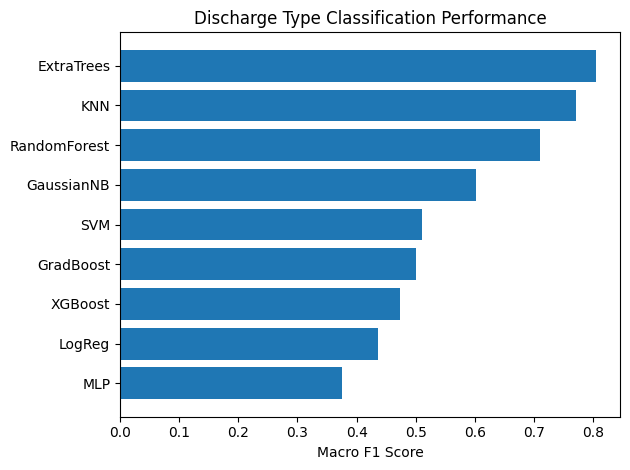

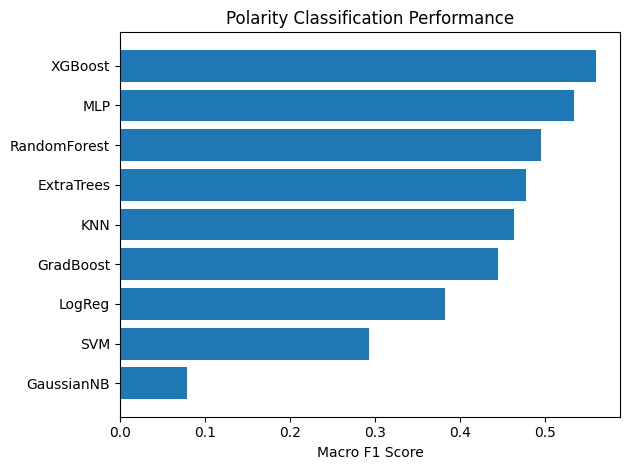

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# KIND RESULTS
kind_data = {
    "Model": ["ExtraTrees","KNN","RandomForest","GaussianNB","SVM","GradBoost","XGBoost","LogReg","MLP"],
    "Macro F1": [0.805,0.771,0.710,0.601,0.511,0.501,0.474,0.437,0.375]
}

kind_df = pd.DataFrame(kind_data).sort_values("Macro F1", ascending=True)

plt.figure()
plt.barh(kind_df["Model"], kind_df["Macro F1"])
plt.xlabel("Macro F1 Score")
plt.title("Discharge Type Classification Performance")
plt.tight_layout()
plt.show()

# POLARITY RESULTS
pol_data = {
    "Model": ["XGBoost","MLP","RandomForest","ExtraTrees","KNN","GradBoost","LogReg","SVM","GaussianNB"],
    "Macro F1": [0.560,0.534,0.495,0.478,0.463,0.444,0.382,0.293,0.079]
}

pol_df = pd.DataFrame(pol_data).sort_values("Macro F1", ascending=True)

plt.figure()
plt.barh(pol_df["Model"], pol_df["Macro F1"])
plt.xlabel("Macro F1 Score")
plt.title("Polarity Classification Performance")
plt.tight_layout()
plt.show()

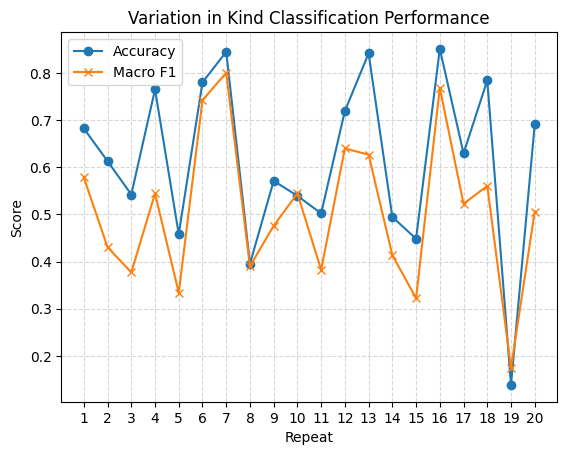

<Figure size 640x480 with 0 Axes>

In [21]:
plt.figure()
plt.plot(kind_repeats["repeat"], kind_repeats["accuracy"], marker='o', label="Accuracy")
plt.plot(kind_repeats["repeat"], kind_repeats["macro_f1"], marker='x', label="Macro F1")

plt.xlabel("Repeat")
plt.ylabel("Score")
plt.title("Variation in Kind Classification Performance")

plt.xticks(range(1, 21))
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend()
plt.show()
plt.savefig("accuracy_vs_split.png", dpi=300, bbox_inches='tight')

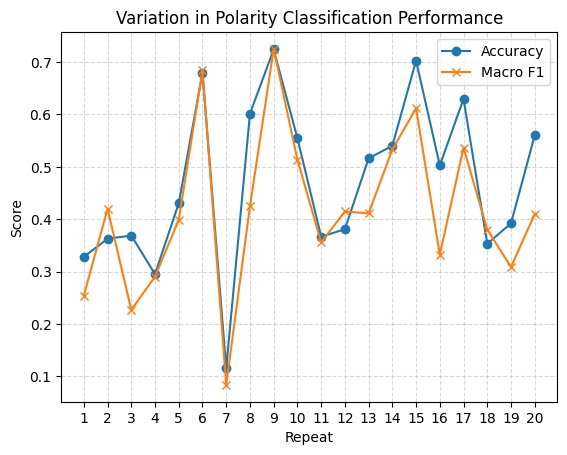

<Figure size 640x480 with 0 Axes>

In [22]:
plt.figure()
plt.plot(pol_repeats["repeat"], pol_repeats["accuracy"], marker='o', label="Accuracy")
plt.plot(pol_repeats["repeat"], pol_repeats["macro_f1"], marker='x', label="Macro F1")

plt.xlabel("Repeat")
plt.ylabel("Score")
plt.title("Variation in Polarity Classification Performance")

plt.xticks(range(1, 21))
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend()
plt.show()
plt.savefig("accuracy_vs_split.png", dpi=300, bbox_inches='tight')

In [23]:
import pandas as pd
import numpy as np

# merge kind + polarity by repeat
merged = kind_repeats.merge(
    pol_repeats,
    on="repeat",
    suffixes=("_kind", "_pol")
)

# find rows
best_kind = merged.loc[merged["macro_f1_kind"].idxmax()]
worst_kind = merged.loc[merged["macro_f1_kind"].idxmin()]
best_pol = merged.loc[merged["macro_f1_pol"].idxmax()]

# find balance (closest to mean performance)
mean_kind = merged["macro_f1_kind"].mean()
mean_pol = merged["macro_f1_pol"].mean()

merged["distance"] = (
    abs(merged["macro_f1_kind"] - mean_kind) +
    abs(merged["macro_f1_pol"] - mean_pol)
)

balanced = merged.loc[merged["distance"].idxmin()]

# combine into final table
selected = pd.DataFrame([
    ["Best Kind", best_kind],
    ["Worst Kind", worst_kind],
    ["Best Polarity", best_pol],
    ["Balanced", balanced]
], columns=["Case", "Data"])

# expand columns
selected_df = pd.DataFrame({
    "Case": selected["Case"],
    "Repeat": selected["Data"].apply(lambda x: x["repeat"]),
    "Kind Accuracy": selected["Data"].apply(lambda x: round(x["accuracy_kind"],3)),
    "Kind Macro F1": selected["Data"].apply(lambda x: round(x["macro_f1_kind"],3)),
    "Polarity Accuracy": selected["Data"].apply(lambda x: round(x["accuracy_pol"],3)),
    "Polarity Macro F1": selected["Data"].apply(lambda x: round(x["macro_f1_pol"],3)),
})

selected_df

,Case,Repeat,Kind Accuracy,Kind Macro F1,Polarity Accuracy,Polarity Macro F1
0,Best Kind,7,0.845,0.800,0.115,0.084
1,Worst Kind,19,0.138,0.175,0.392,0.309
2,Best Polarity,9,0.571,0.476,0.724,0.725
3,Balanced,20,0.691,0.506,0.560,0.410
